# Cosine-latitude weighting: effect on PDSIâ€“NINO3.4 correlation maps

Compare three versions of the OWDA PDSI field when computing gridpoint correlations with NINO3.4:

1. **Raw PDSI** â€“ no weighting  
2. **cos-lat weighted** â€“ `pdsi Ã— cos(lat)`  
3. **sqrt(cos-lat) weighted** â€“ `pdsi Ã— sqrt(cos(lat))` (as used in the paper)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         12,
    'axes.titlesize':    12,
    'pdf.fonttype':      42,
})

## 1. Load data

In [2]:
# OWDA
_coder  = xr.coders.CFDatetimeCoder(use_cftime=True)
owda    = xr.open_dataset('../data/owda.nc', decode_times=_coder)
owda    = owda.assign_coords(Year=owda.time).swap_dims({'time': 'Year'})
owda    = owda.sel(Year=slice(1500, 1800))
owda_eu = owda.sel(lat=slice(35, 70), lon=slice(-15, 35))

lon = owda_eu['lon'].values
lat = owda_eu['lat'].values
lon2d, lat2d = np.meshgrid(lon, lat)

print('OWDA Europe:', dict(owda_eu.sizes))

OWDA Europe: {'lon': 94, 'lat': 70, 'Year': 301}


In [3]:
# NINO3.4 from famine CSV (one value per year)
famine  = pd.read_csv('../processed data/famine_region_data.csv')
nino34  = famine.groupby('Year')['nino34'].first().loc[1500:1800]

print(f'NINO3.4: {nino34.index[0]}â€“{nino34.index[-1]}, n={len(nino34)}')

NINO3.4: 1500â€“1800, n=301


## 2. Build three weighted PDSI fields

In [4]:
pdsi_raw  = owda_eu['pdsi']  # (Year, lat, lon)

w_cos     = np.cos(np.deg2rad(owda_eu['lat']))          # (lat,)
w_sqrtcos = np.sqrt(np.cos(np.deg2rad(owda_eu['lat'])) + 1e-6)  # (lat,) â€” paper version

pdsi_cos     = pdsi_raw * w_cos
pdsi_sqrtcos = pdsi_raw * w_sqrtcos

fields = {
    'Raw PDSI':            pdsi_raw.transpose('Year', 'lat', 'lon'),
    'cos(lat) weighted':   pdsi_cos.transpose('Year', 'lat', 'lon'),
    'sqrt(cos(lat)) weighted\n(paper)': pdsi_sqrtcos.transpose('Year', 'lat', 'lon'),
}

print('Fields built.')

Fields built.


## 3. Compute gridpoint correlations with NINO3.4

In [5]:
def corr_grid(da, nino_series):
    """Pearson r and p-value at each gridpoint. da: (Year, lat, lon)."""
    years  = da['Year'].values.astype(int)
    nino_v = nino_series.reindex(years).values
    data   = da.values  # (Year, lat, lon)

    nlat, nlon = data.shape[1], data.shape[2]
    corrs = np.full((nlat, nlon), np.nan)
    pvals = np.full((nlat, nlon), np.nan)

    for i in range(nlat):
        for j in range(nlon):
            ts   = data[:, i, j]
            mask = np.isfinite(ts) & np.isfinite(nino_v)
            if mask.sum() > 10:
                r, p = pearsonr(ts[mask], nino_v[mask])
                corrs[i, j] = r
                pvals[i, j] = p
    return corrs, pvals


results = {}
for label, da in fields.items():
    print(f'Computing: {label.replace(chr(10), " ")}...')
    corrs, pvals = corr_grid(da, nino34)
    results[label] = (corrs, pvals)

print('Done.')

Computing: Raw PDSI...


Computing: cos(lat) weighted...


Computing: sqrt(cos(lat)) weighted (paper)...


Done.


## 4. Combined 6-panel figure

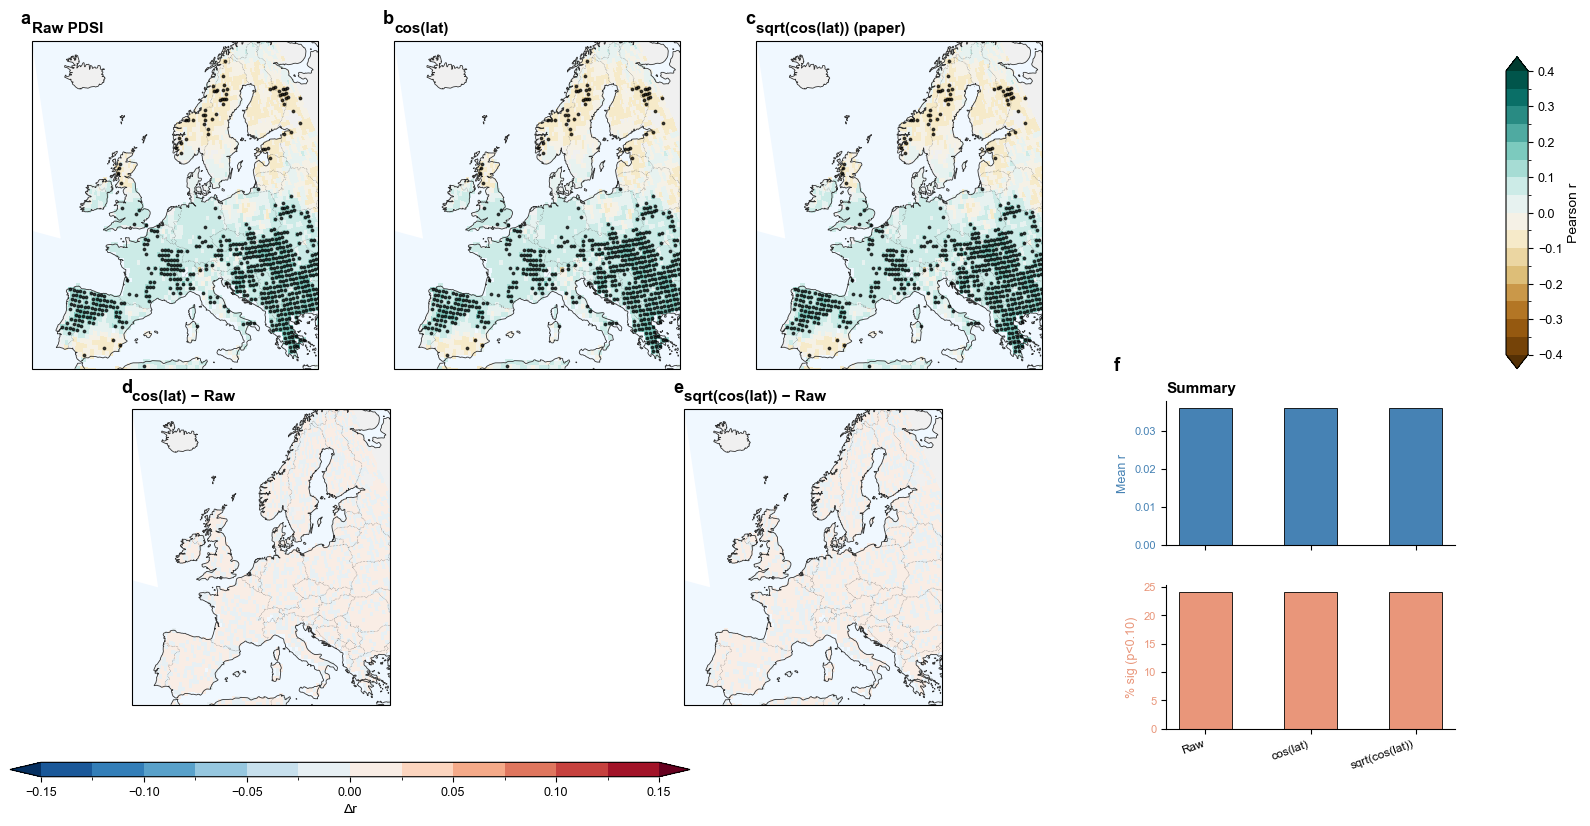

Weighting                                Mean r   Median r  % sig (p<0.10)
-----------------------------------------------------------------------------
Raw PDSI                                    0.036      0.042            24.2%
cos(lat) weighted                           0.036      0.042            24.2%
sqrt(cos(lat)) weighted (paper)             0.036      0.042            24.2%


In [6]:
proj   = ccrs.EuroPP()
extent = [-12, 36, 35, 71]

levels   = np.linspace(-0.4, 0.4, 17)
cmap     = plt.get_cmap("BrBG")
norm     = BoundaryNorm(levels, ncolors=cmap.N, extend="both")

levels_d = np.linspace(-0.15, 0.15, 13)
cmap_d   = plt.get_cmap("RdBu_r")
norm_d   = BoundaryNorm(levels_d, ncolors=cmap_d.N, extend="both")

key_sqrt   = [k for k in results if "sqrt" in k][0]
raw_corr   = results["Raw PDSI"][0]
short_lbls = ["Raw PDSI", "cos(lat)", "sqrt(cos(lat)) (paper)"]

diff_items = [
    ("cos(lat) − Raw",        results["cos(lat) weighted"][0] - raw_corr),
    ("sqrt(cos(lat)) − Raw",  results[key_sqrt][0]            - raw_corr),
]

stat_labels, mean_rs, pct_sigs = [], [], []
for label, (corrs, pvals) in results.items():
    valid = np.isfinite(corrs)
    stat_labels.append(label.replace(chr(10), " "))
    mean_rs.append(np.nanmean(corrs))
    pct_sigs.append((pvals[valid] <= 0.10).mean() * 100)

# Separate gridspecs for each row so row-1 can have only 2 map cols.
# Bar chart is a fully manual axes. Colorbars at far right (x=0.91).
fig = plt.figure(figsize=(17, 8))

gs_r0 = gridspec.GridSpec(
    1, 3, figure=fig,
    left=0.03, right=0.65,
    top=0.93,  bottom=0.52,
    wspace=0.10,
)
gs_r1 = gridspec.GridSpec(
    1, 2, figure=fig,
    left=0.03, right=0.65,
    top=0.47,  bottom=0.10,
    wspace=0.10,
)

# Summary panel: two stacked bar axes (no twinx)
ax_top = fig.add_axes([0.71, 0.30, 0.17, 0.18])  # mean r
ax_bot = fig.add_axes([0.71, 0.07, 0.17, 0.18])  # % sig

# Colorbars: corr on far right; diff as horizontal bar below diff maps
cax1 = fig.add_axes([0.91, 0.52, 0.013, 0.39])   # corr (row 0), vertical
cax2 = fig.add_axes([0.03, 0.01, 0.40, 0.018])   # diff (row 1), horizontal below maps

panel = ord("a")

# Row 0: 3 correlation maps
for col_i, (label, (corrs, pvals)) in enumerate(results.items()):
    ax = fig.add_subplot(gs_r0[0, col_i], projection=proj)
    im = ax.pcolormesh(lon2d, lat2d, corrs, transform=ccrs.PlateCarree(),
                       cmap=cmap, norm=norm, shading="auto")
    sig = pvals <= 0.10
    ax.scatter(lon2d[sig], lat2d[sig], s=3, color="black",
               transform=ccrs.PlateCarree(), zorder=5, alpha=0.7)
    ax.coastlines(linewidth=0.6, color="#333333")
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.4, edgecolor="#666666")
    ax.add_feature(cfeature.LAND,  facecolor="#f0f0f0", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(short_lbls[col_i], fontsize=11, fontweight="bold", loc="left")
    ax.text(-0.04, 1.04, chr(panel), transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="bottom")
    panel += 1
    im_corr = im

cb1 = fig.colorbar(im_corr, cax=cax1, extend="both")
cb1.set_label("Pearson r", fontsize=10)
cb1.ax.tick_params(labelsize=9)

# Row 1: 2 difference maps
for col_i, (label, diff) in enumerate(diff_items):
    ax = fig.add_subplot(gs_r1[0, col_i], projection=proj)
    im2 = ax.pcolormesh(lon2d, lat2d, diff, transform=ccrs.PlateCarree(),
                        cmap=cmap_d, norm=norm_d, shading="auto")
    ax.coastlines(linewidth=0.6, color="#333333")
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.4, edgecolor="#666666")
    ax.add_feature(cfeature.LAND,  facecolor="#f0f0f0", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(label, fontsize=11, fontweight="bold", loc="left")
    ax.text(-0.04, 1.04, chr(panel), transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="bottom")
    panel += 1
    im_diff = im2

cb2 = fig.colorbar(im_diff, cax=cax2, extend="both", orientation="horizontal")
cb2.set_label("Δr", fontsize=10)
cb2.ax.tick_params(labelsize=9)

# Summary: two stacked bar charts
x     = np.arange(3)
w     = 0.5
xlbls = ["Raw", "cos(lat)", "sqrt(cos(lat))"]

# Top: mean r
ax_top.bar(x, mean_rs, w, color="steelblue", edgecolor="black", linewidth=0.6)
ax_top.set_xticks(x)
ax_top.set_xticklabels([])
ax_top.set_ylabel("Mean r", fontsize=9, color="steelblue")
ax_top.tick_params(axis="y", labelcolor="steelblue", labelsize=8)
ax_top.set_ylim(bottom=0)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.set_title("Summary", fontsize=11, fontweight="bold", loc="left", pad=6)
ax_top.text(-0.18, 1.18, chr(panel), transform=ax_top.transAxes,
            fontsize=13, fontweight="bold", va="bottom")

# Bottom: % significant
ax_bot.bar(x, pct_sigs, w, color="darksalmon", edgecolor="black", linewidth=0.6)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(xlbls, fontsize=8.5, rotation=20, ha="right")
ax_bot.set_ylabel("% sig (p<0.10)", fontsize=9, color="darksalmon")
ax_bot.tick_params(axis="y", labelcolor="darksalmon", labelsize=8)
ax_bot.set_ylim(bottom=0)
ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)

plt.savefig("../analysis/output/figures/extended data/figED_coslat_combined.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

print("Weighting                                Mean r   Median r  % sig (p<0.10)")
print("-" * 77)
for label, (corrs, pvals) in results.items():
    valid   = np.isfinite(corrs)
    mean_r  = np.nanmean(corrs)
    med_r   = np.nanmedian(corrs)
    pct_sig = (pvals[valid] <= 0.10).mean() * 100
    print(f"{label.replace(chr(10), chr(32)):<40} {mean_r:>8.3f} {med_r:>10.3f} {pct_sig:>15.1f}%")